# Interest Rate & Equity Volatility Analysis (Python, Pandas)

## Executive Summary
- Built a reproducible risk analysis pipeline using FRED data (10Y Treasury yield: DGS10, S&P 500 index: SP500).
- Quantified equity risk via rolling annualized volatility, drawdowns, and VaR/CVaR.
- Evaluated rate–volatility relationship across multiple horizons and macro regimes (tightening vs easing).

## 1. Setup & Imports

In [1]:
!pip -q install pandas_datareader

In [2]:
from pandas_datareader import data as web

In [3]:
import sys
!{sys.executable} -m pip install pandas_datareader

In [4]:
import sys
print(sys.executable)

/Users/panny/anaconda3/bin/python


In [5]:
import sys
!{sys.executable} -m pip install pandas_datareader


In [6]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas_datareader


In [7]:
from pandas_datareader import data as web
print("pandas_datareader is ready!")


pandas_datareader is ready!


## 2. Data Collection (FRED)
pull:
- DGS10: 10-Year Treasury Constant Maturity Rate (%)
- SP500: S&P 500 Index level

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as web

plt.rcParams["figure.figsize"] = (16,5)

start = "2015-01-01"
end = "2026-02-28"

rate = web.DataReader("DGS10", "fred", start, end)
spx = web.DataReader("SP500", "fred", start, end)

rate.head(), spx.head()

(            DGS10
 DATE             
 2015-01-01    NaN
 2015-01-02   2.12
 2015-01-05   2.04
 2015-01-06   1.97
 2015-01-07   1.96,
               SP500
 DATE               
 2016-02-29  1932.23
 2016-03-01  1978.35
 2016-03-02  1986.45
 2016-03-03  1993.40
 2016-03-04  1999.99)

## 3. Data Cleaning & Alignment
- Align the two series by date
- Drop missing values to ensure consistent calculations

In [9]:
df = pd.concat([rate, spx], axis=1)
df.columns = ["rate_10y", "spx"]
df = df.dropna()

df.head()

,rate_10y,spx
DATE,,
2016-02-29,1.74,1932.23
2016-03-01,1.83,1978.35
2016-03-02,1.84,1986.45
2016-03-03,1.83,1993.40
2016-03-04,1.88,1999.99


## 4. Feature Engineering
- spx_ret: daily return of S&P 500
- vol_30d: 30-day rolling annualized volatility (using 252 trading days)
- rate_change_1d: 1-day change in 10Y yield
- rate_change_hd: h-day change in 10Y yield (multi-horizon)

In [10]:
# returns
df["spx_ret"] = df["spx"].pct_change()

# 30 day rolling annualized  volatility
df["vol_30d"] = df["spx_ret"].rolling(30).std() * np.sqrt(252)

# rate change
df["rate_change"] = df["rate_10y"].diff()

df = df.dropna()

df.head()

,rate_10y,spx,spx_ret,vol_30d,rate_change
DATE,,,,,
2016-04-12,1.79,2061.72,0.009662,0.119588,0.06
2016-04-13,1.77,2082.42,0.010040,0.103431,-0.02
2016-04-14,1.80,2082.78,0.000173,0.103276,0.03
2016-04-15,1.76,2080.73,-0.000984,0.103378,-0.04
2016-04-18,1.78,2094.34,0.006541,0.104303,0.02


## 5. Exploratory Plots
Visualize rates, SPX level, and equity volatility over time.

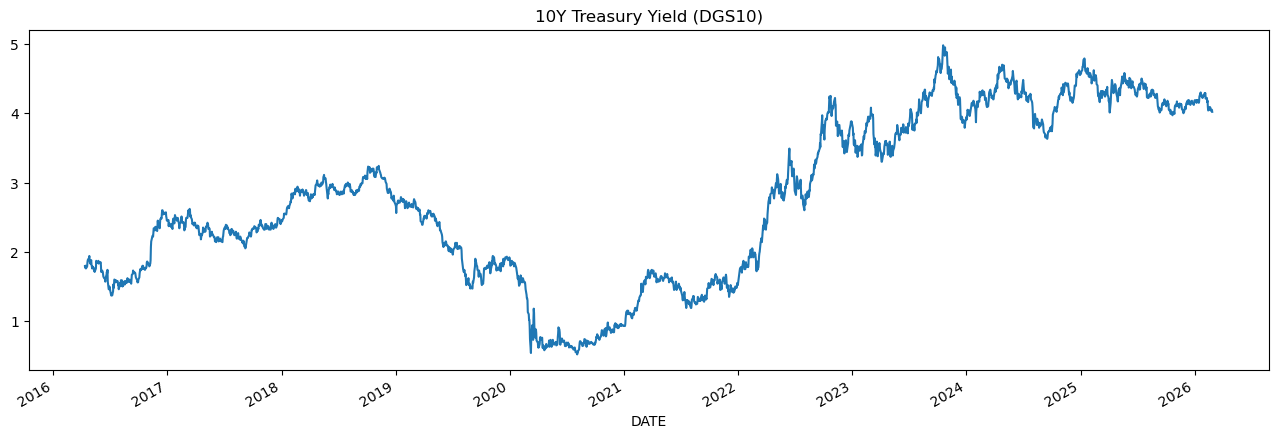

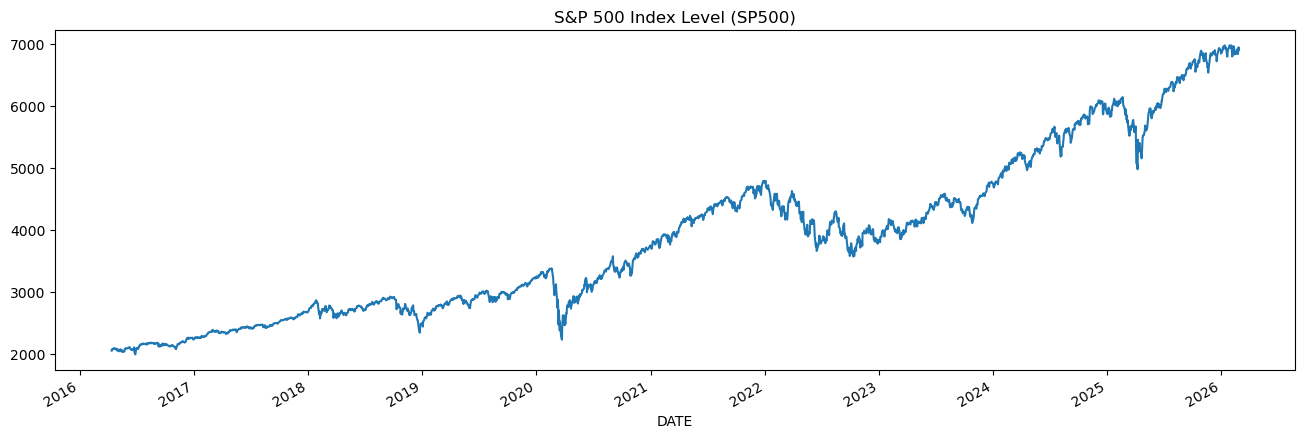

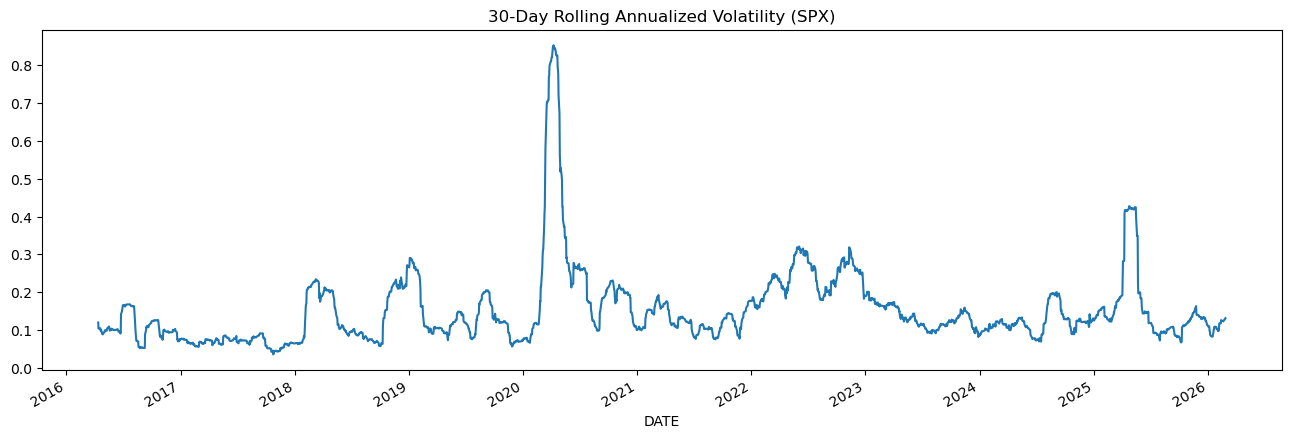

In [11]:
df["rate_10y"].plot(title="10Y Treasury Yield (DGS10)")
plt.show()

df["spx"].plot(title="S&P 500 Index Level (SP500)")
plt.show()

df["vol_30d"].plot(title="30-Day Rolling Annualized Volatility (SPX)")
plt.show()

## 6. Correlation Analysis
examine the relationship between interest rate changes and equity volatility:
- Static correlation (full sample)
- Rolling correlation (time-varying)
- Multi-horizon correlation (different rate change horizons)

In [12]:
corr = df["rate_change"].corr(df["vol_30d"])
corr

np.float64(-0.007036714671166071)

In [13]:
df["rate_change_5d"] = df["rate_10y"].diff(5)

corr_5d = df["rate_change_5d"].corr(df["vol_30d"])

corr_5d

np.float64(-0.025607126594199434)

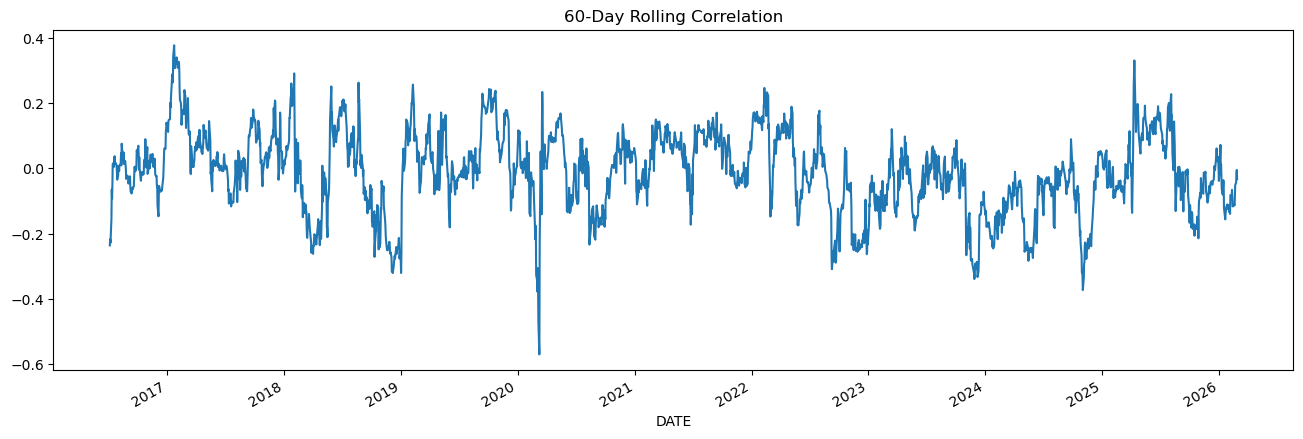

In [14]:
df["rolling_corr_60d"] = df["rate_change"].rolling(60).corr(df["vol_30d"])

df["rolling_corr_60d"].plot(title="60-Day Rolling Correlation")
plt.show()

In [15]:
horizons = [1, 5, 10, 21, 63, 126]

multi_corr = {}

for h in horizons:
    df[f"rate_change_{h}d"] = df["rate_10y"].diff(h)
    multi_corr[f"{h}d"] = df[f"rate_change_{h}d"].corr(df["vol_30d"])

multi_corr

{'1d': np.float64(-0.006898782867160281),
 '5d': np.float64(-0.025607126594199434),
 '10d': np.float64(-0.054651642138725795),
 '21d': np.float64(-0.11826294645580868),
 '63d': np.float64(-0.17739619959989322),
 '126d': np.float64(-0.0655059311825301)}

## 7. Regime Analysis (Tightening vs Easing)
Define rate regimes using the 63-day change in 10Y yield:
- Tightening: rate_trend_63d > 0
- Easing: rate_trend_63d <= 0

compare equity volatility across regimes and test statistical significance.

In [16]:
df["rate_trend_63d"] = df["rate_10y"].diff(63)
df["tightening"] = df["rate_trend_63d"] > 0

vol_tightening = df[df["tightening"]]["vol_30d"].mean()
vol_easing = df[~df["tightening"]]["vol_30d"].mean()

vol_tightening, vol_easing

(np.float64(0.1438856825917083), np.float64(0.15954584515733694))

In [17]:
df.groupby("tightening")["vol_30d"].mean()

tightening
False    0.159546
True     0.143886
Name: vol_30d, dtype: float64

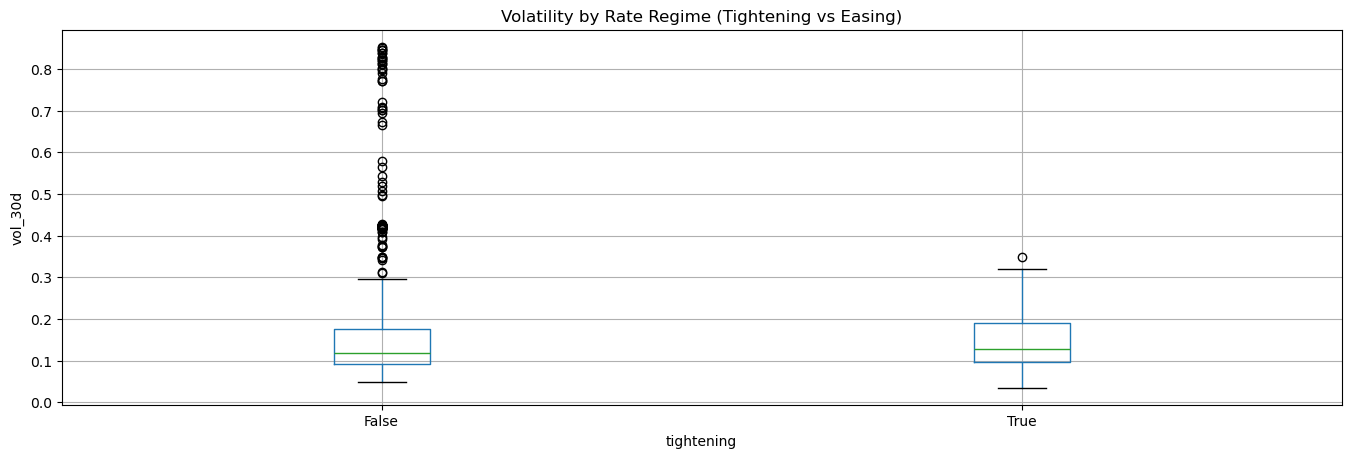

In [18]:
df.boxplot(column="vol_30d", by="tightening")
plt.title("Volatility by Rate Regime (Tightening vs Easing)")
plt.suptitle("")
plt.xlabel("tightening")
plt.ylabel("vol_30d")
plt.show()

In [19]:
from scipy import stats

tight_vol = df[df["tightening"]]["vol_30d"].dropna()
ease_vol = df[~df["tightening"]]["vol_30d"].dropna()

t_stat, p_value = stats.ttest_ind(tight_vol, ease_vol, equal_var=False)

t_stat, p_value

(np.float64(-3.6759182616102413), np.float64(0.00024475301449428794))

## 8. Core Risk Metrics
Compute portfolio-style risk metrics for SPX returns:
- Annualized return, annualized volatility, Sharpe (rf=0)
- Maximum drawdown
- Historical VaR / CVaR at 95% and 99%

In [20]:
# Annualized return
ann_ret = df["spx_ret"].mean() * 252

# Annualized volatility
ann_vol = df["spx_ret"].std() * np.sqrt(252)

# Sharpe ratio
sharpe = ann_ret / ann_vol

# Maximum drawdown
cum = (1 + df["spx_ret"]).cumprod()
peak = cum.cummax()
drawdown = cum / peak - 1
max_dd = drawdown.min()

ann_ret, ann_vol, sharpe, max_dd

(np.float64(0.14103547211044476),
 np.float64(0.18107934124833366),
 np.float64(0.7788600904894368),
 -0.33924959024260615)

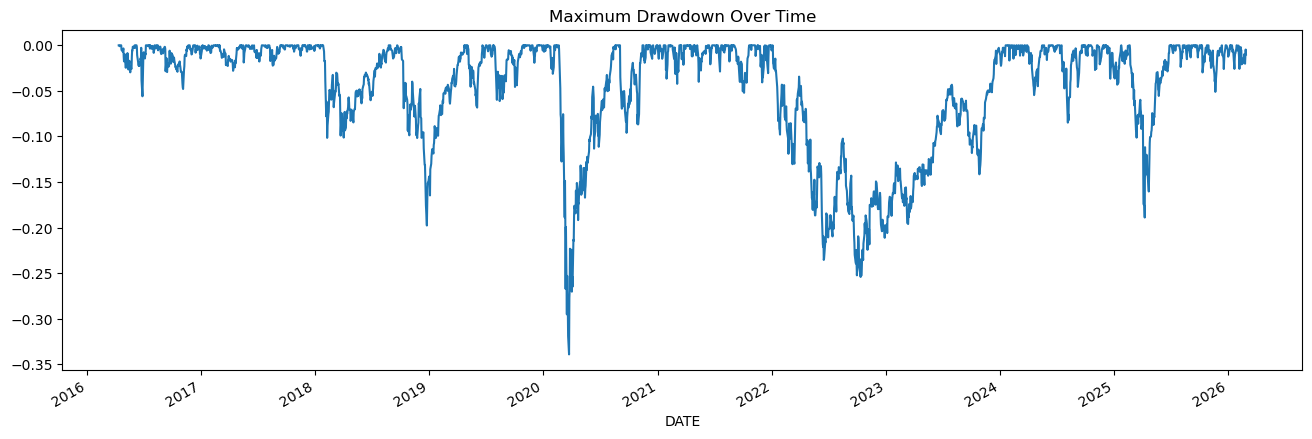

In [21]:
drawdown.plot(title="Maximum Drawdown Over Time")
plt.show()

In [22]:
var_95 = np.percentile(df["spx_ret"], 5)
var_99 = np.percentile(df["spx_ret"], 1)

cvar_95 = df.loc[df["spx_ret"] <= var_95, "spx_ret"].mean()
cvar_99 = df.loc[df["spx_ret"] <= var_99, "spx_ret"].mean()

var_95, cvar_95, var_99, cvar_99

(np.float64(-0.016818740579625235),
 np.float64(-0.027859549002861056),
 np.float64(-0.0335743971242576),
 np.float64(-0.04821860919216325))

## 9. VaR Backtesting (Exceedance Rate)
validate whether the empirical exceedance frequency matches the VaR confidence level.
For 95% VaR, exceedances should be close to 5%.

In [23]:
exceed_95 = (df["spx_ret"] < var_95).mean()
exceed_99 = (df["spx_ret"] < var_99).mean()

exceed_95, exceed_99

(np.float64(0.050283860502838604), np.float64(0.01013787510137875))

## 10. Summary Table

In [24]:
summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio (rf=0)",
        "Maximum Drawdown",
        "1-Day VaR (95%)",
        "1-Day CVaR (95%)",
        "1-Day VaR (99%)",
        "1-Day CVaR (99%)",
        "Regime t-test p-value",
        "VaR 95% Exceedance Rate",
        "VaR 99% Exceedance Rate",
    ],
    "Value": [
        ann_ret,
        ann_vol,
        sharpe,
        max_dd,
        var_95,
        cvar_95,
        var_99,
        cvar_99,
        p_value,
        exceed_95,
        exceed_99,
    ]
})

summary

,Metric,Value
0,Annualized Return,0.141035
1,Annualized Volatility,0.181079
2,Sharpe Ratio (rf=0),0.778860
3,Maximum Drawdown,-0.339250
4,1-Day VaR (95%),-0.016819
5,1-Day CVaR (95%),-0.027860
6,1-Day VaR (99%),-0.033574
7,1-Day CVaR (99%),-0.048219
8,Regime t-test p-value,0.000245
9,VaR 95% Exceedance Rate,0.050284


## 11. Final Risk Findings

- Over the sample, SPX delivered an annualized return of ~14.1% with annualized volatility of ~18.1%, implying a Sharpe (rf=0) of ~0.78.
- Maximum drawdown reached ~-33.9%, highlighting meaningful tail risk during stress periods.
- Historical 1-day VaR is ~-1.68% (95%) and ~-3.36% (99%), with CVaR indicating deeper average losses in the tail.
- Volatility differs significantly across rate regimes (Welch t-test p-value < 0.01).
- Multi-horizon results suggest rate–volatility sensitivity is stronger over medium-term rate moves (e.g., 21d/63d) than single-day changes.
- VaR backtesting via exceedance rates provides a basic calibration check for the chosen confidence levels.